# Algorytmy Macierzowe — operacje na macierzach hierarchicznych

### Krzysztof Kopel, Marcin Szulc

## Cel laboratorium
Celem laboratorium było zapoznanie się z operacjami na macierzach hierarchicznych (skompresowanych), w szczególności z:
- mnożeniem macierzy skompresowanej przez wektor
- dodawaniem dwóch macierzy skompresowanych
- mnożeniem dwóch macierzy skompresowanych
Poza implementacją wymienionych algorytmów, naszym zadaniem było także przeprowadzenie analizy ich złożoności obliczeniowej w sposób eksperymentalny, oraz oszacowanie błędu, jaki popełniamy w porównaniu do operacji na macierzach nieskompresowanych.

## Ustalenia techniczne
Do realizacji zadań w ramach laboratorium użyliśmy języka Python w wersji 3.12. Macierze zapisywaliśmy jako NumPy nd-arrays. Nie implementowaliśmy własnego SVD, zamiast tego wykorzystaliśmy wersję dostępną w bibliotece SciPy. Wykorzystaliśmy algorytm kompresji i rysowacze z poprzedniego laboratorium.

## Zastosowane algorytmy
### Mnożenie macierzy hierarchicznej przez wektor
Algorytm wykorzystuje strukturę drzewa, jaką zastosowaliśmy przy kompresji macierzy. Można opisać go następujacym pseudokodem (dla węzła drzewa *v* i wektora *X*):
1. Jeśli dany węzeł drzewa jest liściem, sprawdź, czy jego rank wynosi 0 - jeśli tak, zwróć macierz z samymi zerami, a jeśli nie, zwróć $v.U * (v.V * X)$, gdzie $v.U$ i $v.V$ to odpowiednie wektory zwrócone przez SVD.
2. Jeśli dany węzeł nie jest liściem (czyli ma dzieci, nazwane tutaj $v_1$ do $v_4$), podziel wektor na dwie części ($X_1$ i $X_2$) i pomnóż według poniższego schematu:
$$
\begin{bmatrix}
v_{11} & v_{12}\\
v_{21} & v_{22}\\
\end{bmatrix}
\begin{bmatrix}
X_1 \\
X_2 \\
\end{bmatrix}
=
\begin{bmatrix}
Y_1^{(1)} + Y_1^{(2)}\\
Y_2^{(1)} + Y_2^{(2)}\\
\end{bmatrix}
$$

gdzie:
- $Y_1^{(1)}$ = matrix_vector_mult($v_1$, $X_1$)
- $Y_1^{(2)}$ = matrix_vector_mult($v_2$, $X_2$)
- $Y_2^{(1)}$ = matrix_vector_mult($v_3$, $X_1$)
- $Y_2^{(2)}$ = matrix_vector_mult($v_4$, $X_2$)

Powyższy algorytm może mieć (dla rank-1) złożoność $O(n log(n))$, ponieważ drzewo ma $log(n)$ pięter, a każde piętro wymaga wykonania liniowej liczby operacji (ponieważ mnożenie wektorów jest liniowe).

Poniżej prezentujemy najważniejszy fragment kodu:
```Python
def matrix_vector_mult(treeNode: TreeNode, vector: np.ndarray) -> np.ndarray:
    if not treeNode.children:
        if treeNode.rank == 0:
            return np.zeros(treeNode.matrix.shape[0], dtype=vector.dtype)
        return treeNode.svd.U @ (treeNode.svd.V @ vector)

    rows = treeNode.matrix.shape[0]
    X1 = vector[:rows // 2]
    X2 = vector[rows // 2:]

    Y1 = CompressedMatrixOperations.matrix_vector_mult(treeNode.children[0], X1)
    Y2 = CompressedMatrixOperations.matrix_vector_mult(treeNode.children[1], X2)
    Y3 = CompressedMatrixOperations.matrix_vector_mult(treeNode.children[2], X1)
    Y4 = CompressedMatrixOperations.matrix_vector_mult(treeNode.children[3], X2)

    return np.vstack((Y1 + Y2, Y3 + Y4))
```

### Dodawanie macierzy skompresowanych

- Wejście: dwa węzły drzewa macierzy skompresowanych $A$ i $B$.
- Wyjście: węzeł reprezentujący sumę $A+B$.

- Jeżeli $sons(A)=0$ oraz $sons(B)=0$, to:
    - jeżeli $rank(A)=0$ oraz $rank(B)=0$, zwróć węzeł zerowy,
    - jeżeli $rank(A)>0$ oraz $rank(B)>0$, oblicz sumę reprezentacji
          niskorangowych i zwróć węzeł liściowy.


- Jeżeli $sons(A)>0$ oraz $sons(B)>0$, to:

    - podziel oba węzły na cztery podbloki,
    - dodaj rekurencyjnie odpowiadające sobie bloki,
    - zwróć węzeł wewnętrzny.


- Jeżeli $sons(A)=0$ oraz $sons(B)>0$, to:

    - rozbij węzeł $A$ na cztery podbloki,
    - dodaj rekurencyjnie bloki $A_i + B_i$,
    - zwróć węzeł wewnętrzny.


- Jeżeli $sons(A)>0$ oraz $sons(B)=0$, to:

    - przypadek symetryczny do poprzedniego.


- Jeżeli $A$ i $B$ są skalarami $(1\times 1)$, zwróć węzeł z wartością $A+B$.

```python
@staticmethod
    def matrix_matrix_add(treeNodeA: TreeNode, treeNodeB: TreeNode) -> TreeNode:
        def low_rank_leaf(U, Vt, coords):
            res_node = TreeNode(rank=U.shape[1], coordinates=coords, matrix=None)
            res_node.svd = SVDComponents(
                singular_values=np.ones(U.shape[1]),
                U=U,
                V=Vt
            )
            return res_node

        if not treeNodeA.children and not treeNodeB.children and treeNodeA.matrix is not None and treeNodeB.matrix is not None and treeNodeA.matrix.shape == (
                1, 1) and treeNodeB.matrix.shape == (1, 1):
            val = treeNodeA.matrix[0, 0] + treeNodeB.matrix[0, 0]

            if abs(val) < 1e-15:
                res_node = TreeNode(
                    rank=0,
                    coordinates=treeNodeA.coordinates,
                    matrix=np.array([[val]])
                )
                res_node.svd = SVDComponents(
                    np.array([]),
                    np.empty((1, 0)),
                    np.empty((0, 1))
                )
            else:
                res_node = TreeNode(
                    rank=1,
                    coordinates=treeNodeA.coordinates,
                    matrix=np.array([[val]])
                )
                u_val = 1.0 if val >= 0 else -1.0
                res_node.svd = SVDComponents(
                    singular_values=np.array([abs(val)]),
                    U=np.array([[u_val]]),
                    V=np.array([[1.0]])
                )

            return res_node

        if not treeNodeA.children and not treeNodeB.children and treeNodeA.rank == 0 and treeNodeB.rank == 0:
            n_rows = treeNodeA.coordinates[1] - treeNodeA.coordinates[0]
            n_cols = treeNodeA.coordinates[3] - treeNodeA.coordinates[2]
            res_node = TreeNode(
                rank=0,
                coordinates=treeNodeA.coordinates,
                matrix=None
            )
            res_node.svd = SVDComponents(
                np.array([]),
                np.empty((n_rows, 0)),
                np.empty((0, n_cols))
            )
            return res_node
        if not treeNodeA.children and not treeNodeB.children and treeNodeA.rank != 0 and treeNodeB.rank != 0:
            singularvalues_sqrt_A = np.sqrt(treeNodeA.svd.singular_values)
            singularvalues_sqrt_B = np.sqrt(treeNodeB.svd.singular_values)

            Ua = treeNodeA.svd.U * singularvalues_sqrt_A
            Va = treeNodeA.svd.V * singularvalues_sqrt_A[:, np.newaxis]
            Ub = treeNodeB.svd.U * singularvalues_sqrt_B
            Vb = treeNodeB.svd.V * singularvalues_sqrt_B[:, np.newaxis]

            U = np.hstack([Ua, Ub])
            V = np.vstack([Va, Vb])

            U_new, S_new, V_new = CompressedMatrixOperations.rSVDofCompressed(U, V)

            res_node = TreeNode(
                rank=len(S_new),
                coordinates=treeNodeA.coordinates,
                matrix=None
            )
            res_node.svd = SVDComponents(S_new, U_new, V_new)
            return res_node

        if treeNodeA.children and treeNodeB.children:
            A1, A2, A3, A4 = treeNodeA.children
            B1, B2, B3, B4 = treeNodeB.children

            C1 = CompressedMatrixOperations.matrix_matrix_add(A1, B1)
            C2 = CompressedMatrixOperations.matrix_matrix_add(A2, B2)
            C3 = CompressedMatrixOperations.matrix_matrix_add(A3, B3)
            C4 = CompressedMatrixOperations.matrix_matrix_add(A4, B4)

            res_node = TreeNode(
                rank=0,
                coordinates=treeNodeA.coordinates,
                matrix=None
            )
            res_node.append_child(C1)
            res_node.append_child(C2)
            res_node.append_child(C3)
            res_node.append_child(C4)

            return res_node

        if not treeNodeA.children and treeNodeB.children:
            singularvalues_sqrt = np.sqrt(treeNodeA.svd.singular_values)
            U1 = treeNodeA.svd.U * singularvalues_sqrt
            V1 = treeNodeA.svd.V * singularvalues_sqrt[:, np.newaxis]

            rows = U1.shape[0]
            U11, U12 = U1[:(rows // 2), :], U1[(rows // 2):, :]

            cols = V1.shape[1]
            V11, V12 = V1[:, :cols // 2], V1[:, cols // 2:]

            B1, B2, B3, B4 = treeNodeB.children

            A1 = low_rank_leaf(U11, V11, B1.coordinates)
            A2 = low_rank_leaf(U11, V12, B2.coordinates)
            A3 = low_rank_leaf(U12, V11, B3.coordinates)
            A4 = low_rank_leaf(U12, V12, B4.coordinates)

            C1 = CompressedMatrixOperations.matrix_matrix_add(A1, B1)
            C2 = CompressedMatrixOperations.matrix_matrix_add(A2, B2)
            C3 = CompressedMatrixOperations.matrix_matrix_add(A3, B3)
            C4 = CompressedMatrixOperations.matrix_matrix_add(A4, B4)

            res_node = TreeNode(rank=0, coordinates=treeNodeB.coordinates, matrix=None)
            res_node.append_child(C1)
            res_node.append_child(C2)
            res_node.append_child(C3)
            res_node.append_child(C4)

            return res_node

        if treeNodeA.children and not treeNodeB.children:
            A1, A2, A3, A4 = treeNodeA.children
            singularvalues_sqrt = np.sqrt(treeNodeB.svd.singular_values)
            U1 = treeNodeB.svd.U * singularvalues_sqrt
            V1 = treeNodeB.svd.V * singularvalues_sqrt[:, np.newaxis]

            rows = U1.shape[0]
            U11, U12 = U1[:(rows // 2), :], U1[(rows // 2):, :]

            cols = V1.shape[1]
            V11, V12 = V1[:, :cols // 2], V1[:, cols // 2:]

            B1 = low_rank_leaf(U11, V11, A1.coordinates)
            B2 = low_rank_leaf(U11, V12, A2.coordinates)
            B3 = low_rank_leaf(U12, V11, A3.coordinates)
            B4 = low_rank_leaf(U12, V12, A4.coordinates)

            C1 = CompressedMatrixOperations.matrix_matrix_add(A1, B1)
            C2 = CompressedMatrixOperations.matrix_matrix_add(A2, B2)
            C3 = CompressedMatrixOperations.matrix_matrix_add(A3, B3)
            C4 = CompressedMatrixOperations.matrix_matrix_add(A4, B4)

            res_node = TreeNode(rank=0, coordinates=treeNodeA.coordinates, matrix=None)
            res_node.append_child(C1)
            res_node.append_child(C2)
            res_node.append_child(C3)
            res_node.append_child(C4)

            return res_node
```



### Mnożenie macierzy skompresowanych

- Wejście: dwa węzły drzewa macierzy skompresowanych $A$ i $B$.
- Wyjście: węzeł drzewa reprezentujący iloczyn $A \cdot B$.

- Jeżeli $A$ i $B$ są skalarami $(1\times1)$, to:
    
    - zwróć węzeł zawierający wartość $A \cdot B$.
    

- Jeżeli $sons(A)=0$ oraz $sons(B)=0$ oraz
      $(rank(A)=0$ lub $rank(B)=0)$, to:
    
    - zwróć węzeł zerowy o odpowiednich wymiarach.
    

- Jeżeli $sons(A)=0$ oraz $sons(B)=0$ oraz
      $rank(A)>0$ oraz $rank(B)>0$, to:
    
    - zapisz węzły w postaci niskorangowej:
          $A = U_A \Sigma_A V_A$, $B = U_B \Sigma_B V_B$,
    - oblicz macierz pośrednią
          \[
              M = (\Sigma_A V_A)(U_B \Sigma_B),
          \]
    - zbuduj reprezentację iloczynu
          \[
              A \cdot B = (U_A M) V_B,
          \]
    - zwróć węzeł liściowy.
    

- Jeżeli $sons(A)>0$ oraz $sons(B)>0$, to:
    
    - podziel oba węzły na cztery podbloki:
              \begin{bmatrix} A_1 & A_2 \\ A_3 & A_4 \end{bmatrix}
              \begin{bmatrix} B_1 & B_2 \\ B_3 & B_4 \end{bmatrix}
    - oblicz rekurencyjnie:
          \begin{array}{l}
          C_1 = A_1B_1 + A_2B_3,\\
          C_2 = A_1B_2 + A_2B_4,\\
          C_3 = A_3B_1 + A_4B_3,\\
          C_4 = A_3B_2 + A_4B_4,
          \end{array}
    - zwróć węzeł wewnętrzny z dziećmi $(C_1,C_2,C_3,C_4)$.
    

- Jeżeli $sons(A)=0$ oraz $sons(B)>0$, to:
    
    - rozbij niskorangowy węzeł $A$ na cztery bloki
          zgodne ze strukturą $B$,
    - wykonaj rekurencyjne mnożenie bloków,
    - zsumuj odpowiednie wyniki,
    - zwróć węzeł wewnętrzny.
    

- Jeżeli $sons(A)>0$ oraz $sons(B)=0$, to:
    
    - przypadek symetryczny do poprzedniego.
    
```python
@staticmethod
    def matrix_matrix_mult(treeNodeA: TreeNode, treeNodeB: TreeNode) -> TreeNode:
        def low_rank_leaf(U, Vt, coords):
            node = TreeNode(
                rank=U.shape[1],
                coordinates=coords,
                matrix=None
            )
            node.svd = SVDComponents(
                singular_values=np.ones(U.shape[1]),
                U=U,
                V=Vt
            )
            return node

        if (not treeNodeA.children and not treeNodeB.children
                and treeNodeA.matrix is not None
                and treeNodeB.matrix is not None
                and treeNodeA.matrix.shape == (1, 1)
                and treeNodeB.matrix.shape == (1, 1)):

            val = treeNodeA.matrix[0, 0] * treeNodeB.matrix[0, 0]

            # Sprawdzamy, czy wartość można uznać za 0
            if abs(val) < 1e-15:
                res = TreeNode(
                    rank=0,
                    coordinates=treeNodeA.coordinates,
                    matrix=np.array([[val]])
                )
                res.svd = SVDComponents(
                    singular_values=np.array([]),
                    U=np.empty((1, 0)),
                    V=np.empty((0, 1))
                )
            else:
                res = TreeNode(
                    rank=1,
                    coordinates=treeNodeA.coordinates,
                    matrix=np.array([[val]])
                )
                u_val = 1.0 if val >= 0 else -1.0
                res.svd = SVDComponents(
                    singular_values=np.array([abs(val)]),
                    U=np.array([[u_val]]),
                    V=np.array([[1.0]])
                )

            return res

        if not treeNodeA.children and not treeNodeB.children and (treeNodeA.rank == 0 or treeNodeB.rank == 0):
            res_node = TreeNode(
                rank=0,
                coordinates=treeNodeA.coordinates,
                matrix=None
            )
            res_node.svd = SVDComponents(
                singular_values=np.array([]),
                U=np.empty((treeNodeA.svd.U.shape[0], 0)),
                V=np.empty((0, treeNodeB.svd.V.shape[1]))
            )
            return res_node

        if not treeNodeA.children and not treeNodeB.children and treeNodeA.rank != 0 and treeNodeB.rank != 0:
            V = treeNodeA.svd.V * treeNodeA.svd.singular_values[:, np.newaxis]
            U = treeNodeB.svd.U * treeNodeB.svd.singular_values

            M = V @ U

            U_new = treeNodeA.svd.U @ M
            V_new = treeNodeB.svd.V

            res = TreeNode(
                rank=U_new.shape[1],
                coordinates=treeNodeA.coordinates,
                matrix=None
            )
            res.svd = SVDComponents(
                singular_values=np.ones(U_new.shape[1]),
                U=U_new,
                V=V_new
            )
            return res

        if treeNodeA.children and treeNodeB.children:
            A1, A2, A3, A4 = treeNodeA.children
            B1, B2, B3, B4 = treeNodeB.children

            C1 = CompressedMatrixOperations.matrix_matrix_add(CompressedMatrixOperations.matrix_matrix_mult(A1, B1),
                                                              CompressedMatrixOperations.matrix_matrix_mult(A2, B3))
            C2 = CompressedMatrixOperations.matrix_matrix_add(CompressedMatrixOperations.matrix_matrix_mult(A1, B2),
                                                              CompressedMatrixOperations.matrix_matrix_mult(A2, B4))
            C3 = CompressedMatrixOperations.matrix_matrix_add(CompressedMatrixOperations.matrix_matrix_mult(A3, B1),
                                                              CompressedMatrixOperations.matrix_matrix_mult(A4, B3))
            C4 = CompressedMatrixOperations.matrix_matrix_add(CompressedMatrixOperations.matrix_matrix_mult(A3, B2),
                                                              CompressedMatrixOperations.matrix_matrix_mult(A4, B4))

            res_node = TreeNode(
                rank=0,
                coordinates=treeNodeA.coordinates,
                matrix=None
            )
            res_node.append_child(C1)
            res_node.append_child(C2)
            res_node.append_child(C3)
            res_node.append_child(C4)

            return res_node

        if not treeNodeA.children and treeNodeB.children:
            B1, B2, B3, B4 = treeNodeB.children

            s_sqrt = np.sqrt(treeNodeA.svd.singular_values)
            U = treeNodeA.svd.U * s_sqrt
            V = treeNodeA.svd.V * s_sqrt[:, np.newaxis]

            mid_row = U.shape[0] // 2
            U_top = U[:mid_row, :]
            U_bot = U[mid_row:, :]

            mid_col = V.shape[1] // 2
            V_left = V[:, :mid_col]
            V_right = V[:, mid_col:]

            A11 = low_rank_leaf(U_top, V_left, B1.coordinates)
            A12 = low_rank_leaf(U_top, V_right, B2.coordinates)
            A21 = low_rank_leaf(U_bot, V_left, B3.coordinates)
            A22 = low_rank_leaf(U_bot, V_right, B4.coordinates)

            C1 = CompressedMatrixOperations.matrix_matrix_add(
                CompressedMatrixOperations.matrix_matrix_mult(A11, B1),
                CompressedMatrixOperations.matrix_matrix_mult(A12, B3))

            C2 = CompressedMatrixOperations.matrix_matrix_add(
                CompressedMatrixOperations.matrix_matrix_mult(A11, B2),
                CompressedMatrixOperations.matrix_matrix_mult(A12, B4))

            C3 = CompressedMatrixOperations.matrix_matrix_add(
                CompressedMatrixOperations.matrix_matrix_mult(A21, B1),
                CompressedMatrixOperations.matrix_matrix_mult(A22, B3))

            C4 = CompressedMatrixOperations.matrix_matrix_add(
                CompressedMatrixOperations.matrix_matrix_mult(A21, B2),
                CompressedMatrixOperations.matrix_matrix_mult(A22, B4))

            res_node = TreeNode(rank=0, coordinates=treeNodeB.coordinates, matrix=None)
            res_node.append_child(C1)
            res_node.append_child(C2)
            res_node.append_child(C3)
            res_node.append_child(C4)

            return res_node

        if treeNodeA.children and not treeNodeB.children:
            A1, A2, A3, A4 = treeNodeA.children

            s_sqrt = np.sqrt(treeNodeB.svd.singular_values)
            U = treeNodeB.svd.U * s_sqrt
            V = treeNodeB.svd.V * s_sqrt[:, np.newaxis]

            mid_row = U.shape[0] // 2
            U_top = U[:mid_row, :]
            U_bot = U[mid_row:, :]

            mid_col = V.shape[1] // 2
            V_left = V[:, :mid_col]
            V_right = V[:, mid_col:]

            B11 = low_rank_leaf(U_top, V_left, A1.coordinates)
            B12 = low_rank_leaf(U_top, V_right, A2.coordinates)
            B21 = low_rank_leaf(U_bot, V_left, A3.coordinates)
            B22 = low_rank_leaf(U_bot, V_right, A4.coordinates)

            C1 = CompressedMatrixOperations.matrix_matrix_add(
                CompressedMatrixOperations.matrix_matrix_mult(A1, B11),
                CompressedMatrixOperations.matrix_matrix_mult(A2, B21))

            C2 = CompressedMatrixOperations.matrix_matrix_add(
                CompressedMatrixOperations.matrix_matrix_mult(A1, B12),
                CompressedMatrixOperations.matrix_matrix_mult(A2, B22))

            C3 = CompressedMatrixOperations.matrix_matrix_add(
                CompressedMatrixOperations.matrix_matrix_mult(A3, B11),
                CompressedMatrixOperations.matrix_matrix_mult(A4, B21))

            C4 = CompressedMatrixOperations.matrix_matrix_add(
                CompressedMatrixOperations.matrix_matrix_mult(A3, B12),
                CompressedMatrixOperations.matrix_matrix_mult(A4, B22))

            res_node = TreeNode(rank=0, coordinates=treeNodeA.coordinates, matrix=None)
            res_node.append_child(C1)
            res_node.append_child(C2)
            res_node.append_child(C3)
            res_node.append_child(C4)

            return res_node
```


## Generowanie przykładowych macierzy
Zgodnie z poleceniem wygenerowaliśmy w celach testowych przykładowe macierze o rozmiarach postaci $2^{3k}$ x $2^{3k}$, dla $k \in \{2, 3, 4\}$. Wygenerowaliśmy po dwie macierze każdego z tych rozmiarów (aby móc je przez siebie mnożyć) i dodatkowo po jednym wektorze o odpowiednim rozmiarze postaci $2^{3k}$ x $1$, dla tych samych wartości $k$.

In [1]:
import numpy as np

from lab4.CompressedMatrixOperations import CompressedMatrixOperations

example_matrices = []
for k in [2, 3, 4]:
    matrix_a = np.random.rand(2 ** (3 * k), 2 ** (3 * k))
    vector = np.random.rand(2 ** (3 * k), 1)
    example_matrices.append((matrix_a, vector))

Następnie, poddaliśmy wszystkie macierze rekurencyjnej kompresji, wykorzystując do tego celu algorytm z poprzedniego laboratorium. Jako epsilon dla macierzy o rozmiarze $n$ podaliśmy wartość osobliwą nr $\frac{n}{8}$ — dzięki temu uzyskaliśmy kompormis między szybkością działania algorytmu a jakością kompresji. Zapamiętujemy jeden wiersz i jedną kolumnę z macierzy wyjściowych SVD — stąd rank 1.

In [2]:
from TreeNode import TreeNode

matrices_compressed = []
for matrix_a, vector in example_matrices:
    _, sing_values_a, _ = np.linalg.svd(matrix_a)
    matrix_a_comp = TreeNode(1, (0, 0, matrix_a.shape[0], matrix_a.shape[1]), matrix_a)
    matrix_a_comp.compress_matrix(sing_values_a[len(sing_values_a) // 8])

    matrices_compressed.append((matrix_a_comp, vector))

Poniżej przedstawiamy największą macierz w postaci skompresowanej — zarówno w wersji z kwadratami, jak i (w zasadzie jako ciekawostka) jako bitmapę, stosując tym bardziej "szarą" kolorystykę, im większa była dana wartość po kompresji.

Text(0.5, 0.98, 'Wizualizacja macierzy 4096 x 4096 po kompresji')

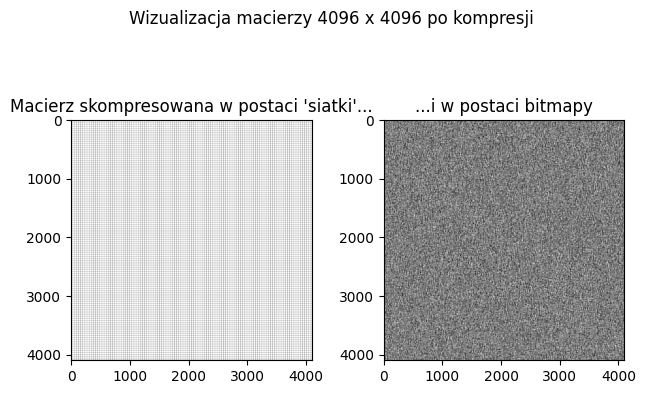

In [3]:
import matplotlib.pyplot as plt

matrix_a = matrices_compressed[-1][0]
fig, ax = plt.subplots(1, 2)
ax[0].imshow(matrix_a.create_structure_image(), cmap="gray")
ax[0].set_title("Macierz skompresowana w postaci 'siatki'...")

ax[1].imshow(matrix_a.reconstruct_image(), cmap="gray")
ax[1].set_title("...i w postaci bitmapy")

fig.tight_layout()
fig.suptitle("Wizualizacja macierzy 4096 x 4096 po kompresji")

Na lewym obrazku widzimy serię dość równomiernie rozłożonych, małych kwadratów. Niektóre z nich wydają się większe — to prawdopodobnie te macierze, które w wyniku kolejnych podziałów szybciej zeszły do postaci możliwej do przedstawienia jako iloczyn dwóch wektorów.

Ciekawy jest także wygląd prawego obrazka — przypomina on trochę obraz wyświetlany przez stare telewizory, gdy ustawiło się je na nieistniejący kanał. Pokazuje to, że taka losowo wygenerowana macierz nie zawiera w sobie żadnego "obrazu", który można by odróżnić gołym okiem.

Jednocześnie odpalenie rysowacza uświadomiło nam, że w tym przypadku nie ma za bardzo sensu dalsze wizualizowanie wyników naszych eksperymentów w taki sposób, jak robiliśmy to przy okazji poprzedniego laboratorium. Skoro nie korzystamy tutaj z bitmapy, a z macierzy wartości losowych, to nie dostaniemy "widzialnych" rezultatów.

## Test algorytmu mnożenia macierzy skompresowanej przez wektor

In [4]:
from time import perf_counter
from CompressedMatrixOperations import CompressedMatrixOperations

# Kluczami w tym słowniku są kolejne wartości
times = {2: [], 3: [], 4: []}

for _ in range(4):
    for matrix_a, vector in matrices_compressed:
        start_time = perf_counter()
        CompressedMatrixOperations.matrix_vector_mult(matrix_a, vector)
        end_time = perf_counter()
        times[np.log2(vector.shape[0]) // 3].append(end_time - start_time)

times = {2 ** (3 * k): np.median(v) for (k, v) in times.items()}

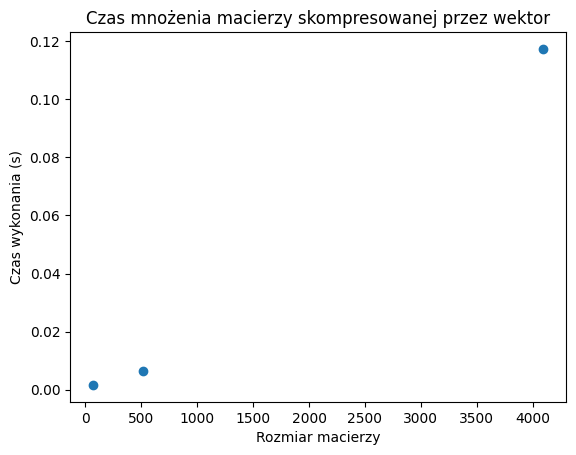

In [5]:
plt.scatter(times.keys(), times.values())
plt.title("Czas mnożenia macierzy skompresowanej przez wektor")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Czas wykonania (s)")
plt.show()

### Analiza złożoności
Zgodnie z poleceniem, do wykresu zależności czasu wykonania od rozmiaru macierzy dopasowaliśmy numerycznie krzywą postaci $$f(N) = \alpha N ^ {\beta}$$

In [6]:
def fun(n, alpha, beta):
    return alpha * (n ** beta)

from scipy.optimize import curve_fit

params, _ = curve_fit(fun, list(times.keys()), list(times.values()))

In [7]:
print(f"Optymalne wartości:\n alpha={params[0]}\n beta={params[1]}")

Optymalne wartości:
 alpha=1.189653930896986e-06
 beta=1.3825709600136455


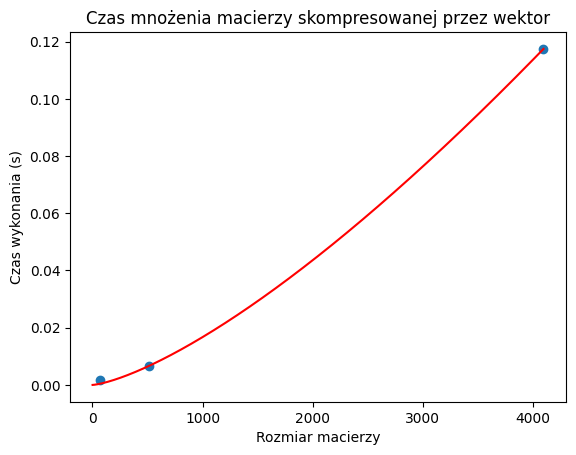

In [8]:
plt.scatter(times.keys(), times.values())
plt.title("Czas mnożenia macierzy skompresowanej przez wektor")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Czas wykonania (s)")
plt.plot(range(1, 4097), [fun(i, params[0], params[1]) for i in range(1, 4097)], color="red")
plt.show()

Na potrzeby naszej analizy najważniejszy jest parametr $\beta$, więc to na nim się skupimy: widzimy, że przybrał on wartość $\approx 1.3$. Oznacza to, że algorytm ma złożoność nieco gorszą od liniowej ($\beta = 1$), ale dużo lepszą od kwadratowej ($\beta = 2$). Może to oznaczać, że estymacja złożoności teoretycznej $O(n log(n))$ jest prawidłowa.

### Porównanie z wynikiem uzyskanym bez kompresji
Do obliczenia normy Frobeniusa wykorzystaliśmy funkcję obliczającą tę normę, dostępną w bibliotece NumPy

Normę policzyliśmy dla największej macierzy.

In [9]:
correct_result = example_matrices[-1][0] @ example_matrices[-1][1]
our_result = CompressedMatrixOperations.matrix_vector_mult(matrices_compressed[-1][0], matrices_compressed[-1][1])

print(f"Norma Frobeniusa = {np.linalg.norm(correct_result - our_result, "fro")}")
print(f"Suma kwadratów macierzy będącej naszym rezultatem = {np.linalg.norm(our_result, "fro")}")

Norma Frobeniusa = 335.7778026950492
Suma kwadratów macierzy będącej naszym rezultatem = 66837.76137240176


Dostaliśmy wartość, która może wydawać się duża, ale jest dwa rzędy wielkości mniejsza od sumy kwadratów elementów naszego wynikowego wektora. Spróbujmy wywołać algorytm dla mniejszej macierzy, ale dużo lepiej skompresowanej.

In [10]:
_, sing_values_a, _ = np.linalg.svd( example_matrices[0][0])

compressed_small = TreeNode(1, (0, 0, example_matrices[0][0].shape[0], example_matrices[0][0].shape[1]), example_matrices[0][0])
compressed_small.compress_matrix(sing_values_a[-1])
correct_result = example_matrices[0][0] @ example_matrices[0][1]
our_result = CompressedMatrixOperations.matrix_vector_mult(compressed_small, example_matrices[0][1])

print(f"Norma Frobeniusa = {np.linalg.norm(correct_result - our_result, "fro")}")
print(f"Suma kwadratów macierzy będącej naszym rezultatem = {np.linalg.norm(our_result, "fro")}")

Norma Frobeniusa = 1.3528330643921842e-14
Suma kwadratów macierzy będącej naszym rezultatem = 116.61136030474422


Widzimy, że jest dużo lepiej! Macierze faktycznie są znacznie bardziej podobne, co pokazuje, że wyższy stopień kompresji faktycznie pomógł uzyskać bardizej precyzyjny wynik.

## Test algorytmu mnożenia macierzy skompresowanej przez macierz skompresowaną

In [21]:
# Kluczami w tym słowniku są kolejne wartości k
times = {2: [], 3: [], 4: []}

for _ in range(4):
    for matrix_a, _ in matrices_compressed:
        start_time = perf_counter()
        CompressedMatrixOperations.matrix_matrix_mult(matrix_a, matrix_a)
        end_time = perf_counter()
        times[np.log2(matrix_a.coordinates[2]) // 3].append(end_time - start_time)

times = {2 ** (3 * k): np.median(v) for (k, v) in times.items()}

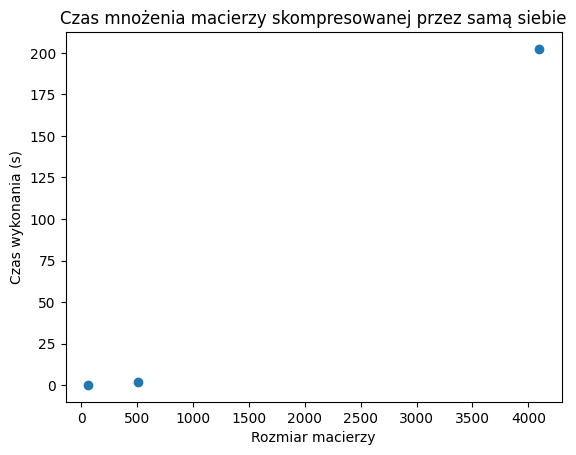

In [22]:
plt.scatter(times.keys(), times.values())
plt.title("Czas mnożenia macierzy skompresowanej przez samą siebie")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Czas wykonania (s)")
plt.show()

### Analiza złożoności
Zgodnie z poleceniem, do wykresu zależności czasu wykonania od rozmiaru macierzy dopasowaliśmy numerycznie krzywą postaci $$f(N) = \alpha N ^ {\beta}$$

In [23]:
params, _ = curve_fit(fun, list(times.keys()), list(times.values()))

In [24]:
print(f"Optymalne wartości:\n alpha={params[0]}\n beta={params[1]}")

Optymalne wartości:
 alpha=1.750985151216373e-06
 beta=2.2320341990902604


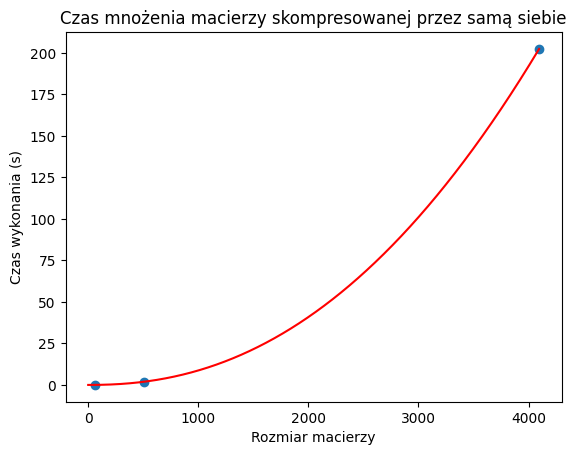

In [25]:
plt.scatter(times.keys(), times.values())
plt.title("Czas mnożenia macierzy skompresowanej przez samą siebie")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Czas wykonania (s)")
plt.plot(range(1, 4097), [fun(i, params[0], params[1]) for i in range(1, 4097)], color="red")
plt.show()

Uzyskana przez nas eksperymentalna złożoność obliczeniowa wyniosła około $O(n^{2.23})$. Wynik ten wydaje się realistyczny i obiecujący. Jest on zauważalnie lepszy niż poznane przez nas wcześniej algorytmy Strassena $O(n^{2.8})$ czy Bineta $O(n^3)$. Pokazuje to, że kompresując macierz, możemy zaoszczędzić czas na jej późniejszym mnożeniu.

### Porównanie z wynikiem uzyskanym bez kompresji
Ponownie porównaliśmy uzyskane przez nasz algorytm wyniki z tymi, które uzyskujemy dla macierzy nieskompresowanej.

In [16]:
correct_result = example_matrices[-1][0] @ example_matrices[-1][0]
our_result = CompressedMatrixOperations.matrix_matrix_mult(matrices_compressed[-1][0], matrices_compressed[-1][0])
our_result = our_result.reconstruct_image((4096, 4096))
print(f"Norma Frobeniusa = {np.linalg.norm(correct_result - our_result, "fro")}")
print(f"Suma kwadratów macierzy będącej naszym rezultatem = {np.linalg.norm(our_result, "fro")}")

Norma Frobeniusa = 4187754.8943955814
Suma kwadratów macierzy będącej naszym rezultatem = 92319.86135171565


Otrzymaliśmy olbrzymi wynik! Spróbujmy ponownie z mniejszą, ale mocniej skompresowaną macierzą.

In [1]:
_, sing_values_a, _ = np.linalg.svd( example_matrices[0][0])

compressed_small = TreeNode(1, (0, 0, example_matrices[0][0].shape[0], example_matrices[0][0].shape[1]), example_matrices[0][0])
compressed_small.compress_matrix(sing_values_a[-1])
correct_result = example_matrices[0][0] @ example_matrices[0][0]
our_result = CompressedMatrixOperations.matrix_matrix_mult(compressed_small, compressed_small)
our_result = our_result.reconstruct_image((64, 64))

print(f"Norma Frobeniusa = {np.linalg.norm(correct_result - our_result, "fro")}")
print(f"Suma kwadratów macierzy będącej naszym rezultatem = {np.linalg.norm(our_result, "fro")}")

Norma Frobeniusa = 1014.4233304251924
Suma kwadratów macierzy będącej naszym rezultatem = 137.53544997563355


Wynik wciąż jest dość duży. Ponownie, można zastanawiać się, czy wynika to z samej kompresji, czy z błędu w algorytmie. Nie jesteśmy pewni, chociaż podejrzewamy, że będzie to ta druga opcja. Mimo licznych prób, nie udało nam się jednak znaleźć elementu, który mógłby nie działać poprawnie.

## Podsumowanie
Laboratorium pozwoliło nam zapoznać się z algorytmami mnożenia i dodawania macierzy skompresowanych. O ile mnożenie macierzy hierarchicznej przez wektor nie sprawiło nam większych problemów, o tyle te pojawiły się przy mnożeniu macierzy hierarchicznej przez samą siebie. Być może wynika to z dużego stopnia skomplikowania algorytmu, który sprawił, że łatwo było coś przeoczyć. Mimo tego była to dla nas cenna lekcja na temat implementacji algorytmów macierzowych, a tematyka macierzy hierarchicznych wydaje się interesująca i przydatna w praktyce inżynieryjnej.